# EDA in pandas and duckdb for Stockholm cultural events (Metrics and KPI) 

In [60]:
# Import (Pandas + DuckDB + Matplotlib)

import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [61]:
# Load data and quick checks/exploration of dataset

df = pd.read_csv("data/events_full_year.csv")

df.head()


,event_id,name,url,image_url,date,time,status,segment,genre,subgenre,venue_name,venue_city,venue_address,venue_lat,venue_lon,day_of_week,month_name,month_num,year,hour
0,Z698xZq2Z16vAkOybO,Labero's Magic World,https://www.ticketmaster.se/event/laberos-magi...,https://s1.ticketm.net/dam/a/f00/7a24bdb3-8f78...,2026-04-11,18:00:00,onsale,Miscellaneous,Food & Drink,Food & Drink,La Botanica,Stockholm,Tel: 08-751 09 65 - Stjärntorget 2,59.368980,18.005850,Saturday,April,4,2026,18
1,Z698xZq2Z16vQo0Eox,Svartklubben - Mat & Musik i Mörker,https://www.ticketmaster.se/event/svartklubben...,https://s1.ticketm.net/dam/a/841/1c1b2a57-616a...,2026-04-11,18:00:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Svartklubben,Stockholm,Södermannagatan 27,59.312090,18.081330,Saturday,April,4,2026,18
2,Z698xZq2Z16vF3k9G0,MAMMA MIA! THE PARTY,https://www.ticketmaster.se/event/mamma-mia-th...,https://s1.ticketm.net/dam/e/d78/e055a3c6-df72...,2026-04-11,19:30:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Tyrol,Stockholm,Lilla Allmänna Gränd 2,59.324127,18.096259,Saturday,April,4,2026,19
3,Z698xZq2Z1k-Skb4F,Bo Kaspers Orkester - Il magnifico,https://www.ticketmaster.se/event/bo-kaspers-o...,https://s1.ticketm.net/dam/e/9f5/189e04cc-d86d...,2026-04-11,19:30:00,onsale,Music,Rock,Pop,Göta Lejon,Stockholm,Götgatan 55,59.313780,18.073840,Saturday,April,4,2026,19
4,Z698xZq2Z1k_y_Mo_,& Julia,https://www.ticketmaster.se/event/-julia-bilje...,https://s1.ticketm.net/dam/a/9d5/39c257d4-fad5...,2026-04-11,19:30:00,onsale,Arts & Theatre,Theatre,Miscellaneous,Cirkus,Stockholm,Djurgårdsslätten 43-45,59.324570,18.099690,Saturday,April,4,2026,19


In [62]:
df.describe()

,venue_lat,venue_lon,month_num,year,hour
count,635.000000,635.000000,635.000000,635.000000,635.000000
mean,59.380313,18.141746,7.168504,2026.042520,17.919685
std,0.183879,0.225299,2.979152,0.201931,2.808534
min,59.290450,18.000410,1.000000,2026.000000,0.000000
25%,59.313780,18.063860,5.000000,2026.000000,18.000000
50%,59.324570,18.081330,6.000000,2026.000000,19.000000
75%,59.336230,18.099690,10.000000,2026.000000,19.000000
max,59.993330,18.890620,12.000000,2027.000000,22.000000


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       635 non-null    str    
 1   name           635 non-null    str    
 2   url            635 non-null    str    
 3   image_url      635 non-null    str    
 4   date           635 non-null    str    
 5   time           635 non-null    str    
 6   status         635 non-null    str    
 7   segment        635 non-null    str    
 8   genre          635 non-null    str    
 9   subgenre       635 non-null    str    
 10  venue_name     635 non-null    str    
 11  venue_city     635 non-null    str    
 12  venue_address  633 non-null    str    
 13  venue_lat      635 non-null    float64
 14  venue_lon      635 non-null    float64
 15  day_of_week    635 non-null    str    
 16  month_name     635 non-null    str    
 17  month_num      635 non-null    int64  
 18  year           635 no

## Connect duckdb (Duckdb sql for analysis ) 

In [64]:
con = duckdb.connect()
con.register("events", df)  #register table "events"in df for queries 

## Events per segment

In [66]:
events_per_segment= con.execute("""
    SELECT segment, COUNT(*) as total_events
    FROM events
    GROUP BY segment
    ORDER BY total_events DESC
    """).df()

events_per_segment

,segment,total_events
0,Arts & Theatre,426
1,Music,152
2,Miscellaneous,53
3,Sports,4


## Events per genre

In [ ]:
events_per_game= con.execute("""
    SELECT genre, COUNT(*) as total_events
    FROM events
    GROUP BY genre
    ORDER BY total_events DESC
    """).df()

events_per_game

,genre,total_events
0,Theatre,93
1,Rock,20
2,Other,12
3,Hip-Hop/Rap,8
4,Dance/Electronic,7
5,Dance,4
6,Latin,3
7,Family,3
8,Comedy,3
9,Alternative,2


## Most repeated events(Top 10)

In [68]:
most_repeated_events= con.execute("""
    SELECT name, COUNT(*) AS occurrences
    FROM events
    GROUP BY name
    ORDER BY occurrences DESC
    LIMIT 10;
    """).df()

most_repeated_events


,name,occurrences
0,MAMMA MIA! THE PARTY,89
1,Torka aldrig tårar utan handskar,52
2,Svartklubben - Mat & Musik i Mörker,40
3,& Julia,36
4,Fredrik ”Benke” Rydman – Romeo & Julia,18
5,Labero's Magic World,15
6,MAFFIA COMEDY SUPERWEEKEND,13
7,Bo Kaspers Orkester - Il magnifico,13
8,Tomten är far till alla barnen,12
9,HippHipp Live!,8


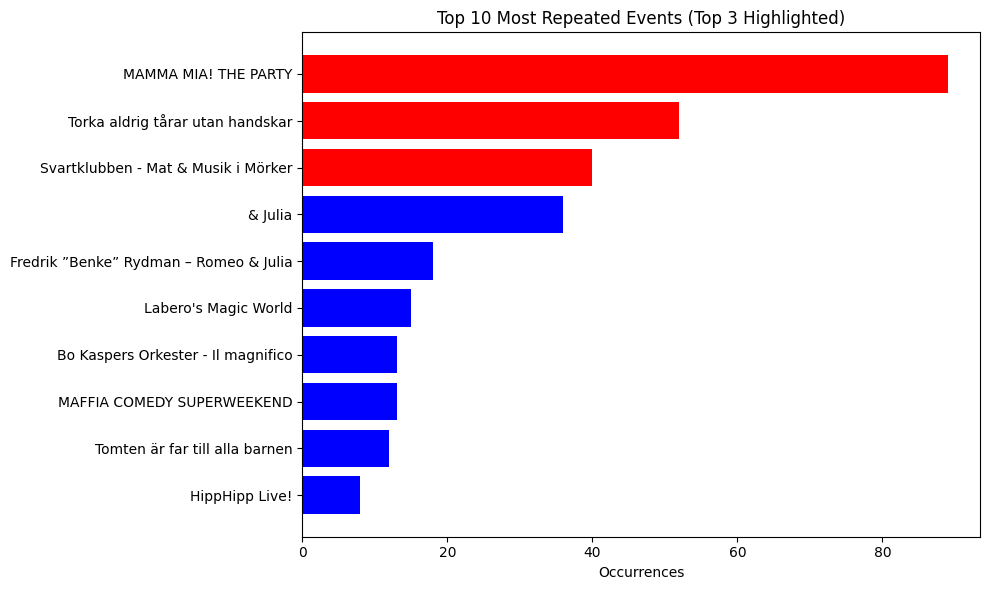

In [72]:
fig, ax = plt.subplots(figsize=(10,6))

data = most_repeated_events.sort_values(by="occurrences", ascending=True)
top3 = data.tail(3)["name"]

colors = ["red" if name in top3.values else "blue"
          for name in data["name"]]

ax.barh(data["name"], data["occurrences"], color=colors)

ax.set_title("Top 10 Most Repeated Events (Top 3 Highlighted)")
ax.set_xlabel("Occurrences")

#for i, v in enumerate(data["occurrences"]):
    #ax.text(v, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Top venues by event volume(Top 10)

In [ ]:
top_venues_by_event_vol= con.execute("""
    SELECT venue_name, COUNT(*) AS total_events
    FROM events
    GROUP BY venue_name
    ORDER BY total_events DESC
    LIMIT 10;
    """).df()

top_venues_by_event_vol

,venue_name,total_events
0,Tyrol,93
1,Unknown Venue,26
2,Strawberry Arena,14
3,Cirkus,5
4,Förbindelsehallen,3
5,B-K,3
6,3Arena,2
7,Fryshuset,2
8,Dansens Hus Studioscen,2
9,Debaser Nova,2


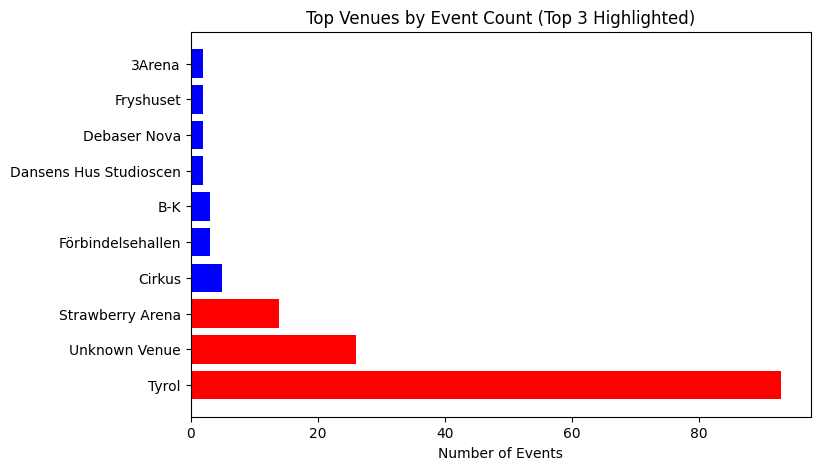

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

# Sort data (important)
data = top_venues_by_event_vol.sort_values(by="total_events", ascending=False)

# Top 3 venues
top3 = data.head(3)["venue_name"]

# Colors (highlight top 3)
colors = ["green" if venue in top3.values else "#grey"
          for venue in data["venue_name"]]

# Plot
ax.bar(data["venue_name"], data["total_events"], color=colors)

# Labels
ax.set_title("Top 10 Venues by Event Volume (Top 3 Highlighted)")
ax.set_xlabel("Venue")
ax.set_ylabel("Number of Events")
ax.tick_params(axis='x', rotation=90)

# Value labels
for i, v in enumerate(data["total_events"]):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Events by day of week

In [ ]:
events_by_day_of_the_week= con.execute("""
    SELECT day_of_week, COUNT(*) AS total_events
    FROM events
    GROUP BY day_of_week
    ORDER BY total_events DESC;
    """).df()

events_by_day_of_the_week

,day_of_week,total_events
0,Saturday,58
1,Friday,39
2,Thursday,29
3,Monday,11
4,Sunday,11
5,Wednesday,8
6,Tuesday,4


## Events by month of the year 

In [ ]:
events_by_month_of_year= con.execute("""
    SELECT month_name, COUNT(*) AS total_events
    FROM events
    GROUP BY month_name
    ORDER BY total_events DESC;
    """).df()

events_by_month_of_year

,month_name,total_events
0,May,33
1,October,24
2,April,22
3,November,22
4,June,17
5,September,16
6,August,14
7,July,10
8,December,2


## Segment - Genre breakdown

In [ ]:
segment_genre= con.execute("""
    SELECT segment, genre, COUNT(*) AS total
    FROM events
    GROUP BY segment, genre
    ORDER BY total DESC;
    """).df()

segment_genre

,segment,genre,total
0,Arts & Theatre,Theatre,93
1,Music,Rock,20
2,Music,Other,12
3,Music,Hip-Hop/Rap,8
4,Music,Dance/Electronic,7
5,Arts & Theatre,Dance,4
6,Music,Latin,3
7,Arts & Theatre,Comedy,3
8,Miscellaneous,Family,3
9,Music,Folk,2


## Peak hours oveerall 

In [ ]:
overall_peak_hours= con.execute("""
    SELECT hour, COUNT(*) AS total_events
    FROM events
    GROUP BY hour
    ORDER BY hour;
    """).df()

overall_peak_hours

,hour,total_events
0,1.0,1
1,13.0,19
2,14.0,1
3,16.0,1
4,17.0,3
5,18.0,51
6,19.0,60
7,20.0,17
8,21.0,2
9,22.0,1


## Filter events(names) with their segments and genre that occur in Strawberry Arena

In [ ]:
events_in_strwb_arena=con.execute("""
   SELECT DISTINCT name, segment, genre
    FROM events
    WHERE venue_name = 'Strawberry Arena'
    """).df()

events_in_strwb_arena

,name,segment,genre
0,Foo Fighters: TAKE COVER TOUR 2026,Music,Rock
1,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Rock
2,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour | ...,Music,Latin
3,The Weeknd: After Hours Til Dawn Tour | VIP Pa...,Music,Other
4,Bad Bunny - DeBÍ TiRAR MáS FOToS World Tour,Music,Latin
5,The Weeknd: After Hours Til Dawn Tour,Music,Other
6,System Of A Down,Music,Rock
7,The Weeknd I Strawberry Arena Premium Experien...,Music,Hip-Hop/Rap
8,The Weeknd : After Hours Til Dawn Tour,Music,Hip-Hop/Rap
9,System Of A Down I VIP Packages,Music,Other
